Load in data to analyse:

In [99]:
import pandas as pd
import numpy as np
import os
import plotly.express as px
import chromatin_tracing_python.image_processing_functions as ip
import chromatin_tracing_python.trace_analysis_functions as tr
import glob

file_list = glob.glob('dist_90_deg_120/*.csv')
traces = []
for i, file in enumerate(file_list):
    trace = pd.read_csv(file)
    trace.reset_index()
    trace.columns = ['frame','x','y','z','QC']
    trace['trace_ID'] = i
    trace['frame_name']=trace['frame']
    traces.append(trace)
traces = pd.concat(traces, axis=0).reset_index(drop=True)

In [100]:
traces

,frame,x,y,z,QC,trace_ID,frame_name
0,0,76.783640,-33.031354,-31.219093,1.0,0,0
1,1,135.999918,6.293288,17.809913,1.0,0,1
2,2,125.424308,41.520929,102.291481,1.0,0,2
3,3,162.609046,80.064960,171.766993,1.0,0,3
4,4,239.509174,72.219636,207.350655,1.0,0,4
...,...,...,...,...,...,...,...
1995,5,88.944151,35.708863,198.342304,1.0,199,5
1996,6,20.130068,-35.409648,224.434378,1.0,199,6
1997,7,-34.344657,-113.250905,233.224420,1.0,199,7
1998,8,-68.336500,-88.118151,312.066446,1.0,199,8


In [101]:
tr.plot_traces(traces,[5])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [102]:
pwds = tr.pwd_calc(traces)

In [103]:
print('Number of traces in analysis: ', pwds.shape[0])
pwds_mean=np.clip(np.round(-np.nanmean(pwds, axis=0),0).astype(int),-800,0)

import plotly.figure_factory as ff
fig = ff.create_annotated_heatmap(pwds_mean,colorscale='hot')
fig.update_layout(
    width = 600,
    height = 600,
    yaxis_autorange="reversed"
)
fig.show()

Number of traces in analysis:  200


Further, we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and three metrics of similarity between the two traces. These are the mse of the alignment, and the mse of the two pair-wise distance matrices, as well as the Pearson's correlation coefficient between the PWDs. We sort the matrix for to find pairs with a high PCC.

In [104]:
pairs = tr.trace_analysis(traces, pwds)

In [105]:
pairs.sort_values(by=['aligned_mse'], ascending=True)

,idx1,idx2,aligned_mse,aligned_pcc,pwd_mse,pwd_pcc
17192,125,193,40.142552,0.951075,30.695612,0.974084
17236,126,164,45.839238,0.964299,64.320169,0.885034
11308,68,123,48.854213,0.950228,66.511736,0.890844
8137,46,65,49.762727,0.893401,57.479002,0.888628
10376,61,129,51.310195,0.983173,32.905659,0.985045
...,...,...,...,...,...,...
12823,80,144,453.465759,-0.703282,87.280332,0.916065
9550,55,146,456.590862,-0.809150,47.543767,0.958095
3191,16,144,461.260701,-0.898666,39.967924,0.987825
14173,92,144,464.524087,-0.893935,99.934447,0.904626


We can visualize the aligned traces by their index in the pair matrix.

In [106]:
fig = tr.plot_aligned_traces(traces, [69,188])

We can immediately use the paired similarity values to group the traces. We can use any of the three similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace.

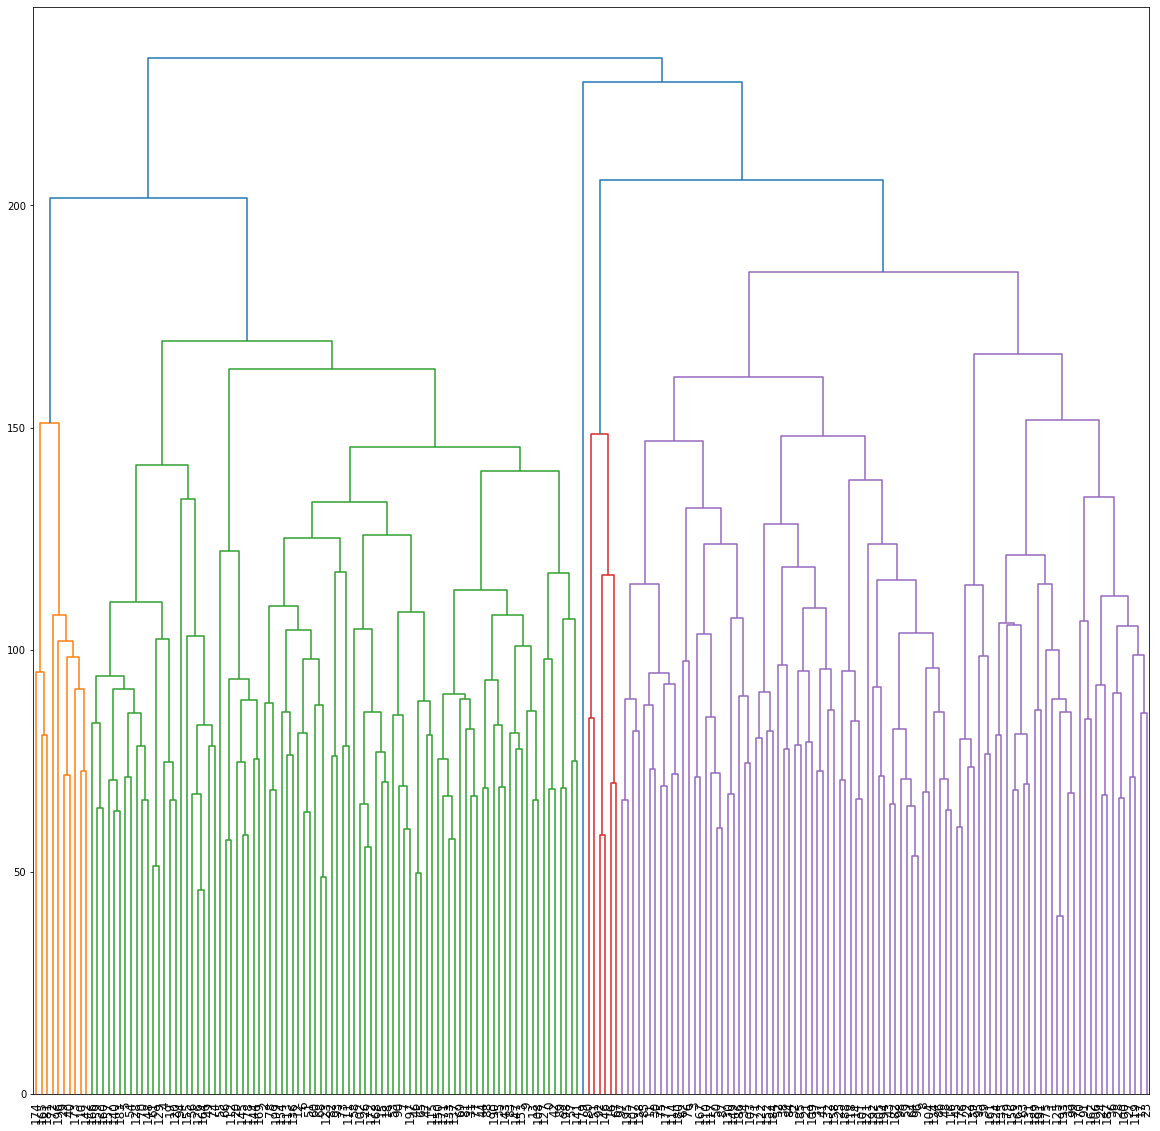

In [107]:
cluster_df = tr.trace_clustering(pairs, metric='aligned_mse', method='average', color_threshold=200)

In [108]:
cluster_id = 3
cluster_members = cluster_df[cluster_df['cluster']==cluster_id]['trace_ID'].values
print(cluster_members)

[ 16  67  80  92 146 151]


In [109]:
clust_aligned, clust_mean = tr.general_procrustes_analysis(traces, cluster_members)
fig = tr.plot_gpa_output(clust_aligned, clust_mean, cluster_members)

Initial distance is 690.4779935360701
GPA converged after 2 cycles with distance 169.3690298931952
[0 1 2 3 4 5 6 7 8 9]


In [110]:
aligned_all_gpa=tr.run_gpa_all_clusters(traces, cluster_df, min_cluster=4)
fig = tr.plot_multi_points(aligned_all_gpa)

[[10, 29, 40, 72, 142, 165, 173, 174, 181, 196], [0, 2, 4, 5, 6, 7, 9, 12, 13, 15, 18, 19, 20, 26, 31, 35, 42, 44, 46, 47, 49, 51, 53, 54, 55, 56, 57, 58, 60, 61, 65, 66, 68, 69, 70, 73, 74, 77, 78, 81, 82, 83, 88, 89, 90, 93, 94, 102, 108, 111, 112, 113, 115, 120, 123, 126, 127, 128, 129, 133, 136, 137, 140, 141, 143, 144, 145, 147, 148, 150, 153, 154, 155, 157, 159, 160, 164, 166, 168, 169, 171, 172, 178, 183, 190, 197, 198, 199], [16, 67, 80, 92, 146, 151], [1, 3, 8, 11, 14, 17, 21, 22, 23, 24, 25, 27, 28, 30, 32, 33, 34, 36, 37, 38, 39, 41, 43, 45, 48, 50, 52, 59, 62, 63, 64, 71, 75, 76, 79, 84, 85, 86, 87, 91, 95, 96, 97, 98, 99, 100, 101, 103, 104, 105, 106, 107, 109, 110, 114, 116, 117, 118, 119, 121, 122, 124, 125, 130, 131, 132, 134, 135, 138, 139, 149, 152, 156, 158, 161, 162, 163, 167, 170, 175, 176, 177, 180, 182, 184, 185, 186, 187, 188, 189, 191, 192, 193, 194, 195]]
Initial distance is 1041.532139914273
GPA converged after 7 cycles with distance 389.84493715172346
Initia

In [111]:
tr.radius_of_gyration(clust_mean)

310.40666265149014

In [112]:
tr.elongation(clust_mean)

Eigenvalues are  [29038.6173505   2844.59267415   234.22204816]


0.9020410428010828

In [113]:
all_trace_ids = list(traces['trace_ID'].unique())
px.bar(x=all_trace_ids, y = [tr.radius_of_gyration(points) for points in tr.points_from_traces(traces, all_trace_ids)])

In [114]:
px.bar(x=all_trace_ids, y=[tr.elongation(points) for points in tr.points_from_traces(traces, all_trace_ids)])

Eigenvalues are  [34782.82993512  1247.97025697   693.04666436]
Eigenvalues are  [18510.10870294  2664.39477723  1405.86447214]
Eigenvalues are  [16121.05177575  4028.10036721   682.8121017 ]
Eigenvalues are  [7853.4401012  4865.99114263 2017.53823905]
Eigenvalues are  [24799.37792334  2525.3517405    412.1846169 ]
Eigenvalues are  [15666.90580906  5622.1344128    699.00174657]
Eigenvalues are  [10668.51204663  5615.48496063   734.83278494]
Eigenvalues are  [30818.57211548  1153.37220573   365.17865656]
Eigenvalues are  [15630.18134421  3705.43946582   391.38470823]
Eigenvalues are  [15987.43359711  6932.42174913   922.86532994]
Eigenvalues are  [13376.05023472  3687.68885928  2421.40033063]
Eigenvalues are  [20501.0171589   3213.22054163   842.31950367]
Eigenvalues are  [12311.71257412  8297.28208948   479.43668333]
Eigenvalues are  [9944.92828921 3209.13520266  407.82768043]
Eigenvalues are  [11816.09623453  2986.55827807   871.71777987]
Eigenvalues are  [11883.83129118  1606.0922426

We can visualize these individually as before. To visualize pairs in the identified grouping, we can look up the index in the pairs analysis and plot these using the paired plotting function as well. Note that for lookups in the pairs dataframe the lower index is always idx1, the higher idx2.